<a href="https://colab.research.google.com/github/rifainareswara/study_regresi_linear_logistik/blob/main/Data_Aset_Ujian_Nasional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 SEDANG MEMUAT DATASET...
✅ Dataset berhasil dimuat!

Contoh 5 Data Teratas:
    ID  Nama  Umur     Gender  Nilai      Matkul    Tanggal   UTS   UAS
0  1.0  Budi  24.0  Laki-laki   85.0       Kimia   9/8/2023  90.0  80.0
1  2.0   Ani  21.0  Perempuan   77.5  Matematika  15/8/2023  75.0  80.0
2  3.0  Joko  20.0  Laki-laki   90.0     Biologi  15/8/2023  85.0  95.0
3  4.0  Siti  21.0  Perempuan   60.0  Matematika   9/8/2023  55.0  65.0
4  5.0  Agus  23.0  Laki-laki   77.5      Fisika   9/8/2023  80.0  75.0

Informasi Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       100 non-null    float64
 1   Nama     100 non-null    object 
 2   Umur     100 non-null    float64
 3   Gender   100 non-null    object 
 4   Nilai    100 non-null    float64
 5   Matkul   100 non-null    object 
 6   Tanggal  100 non-null    object 
 7   UTS      100 non-null

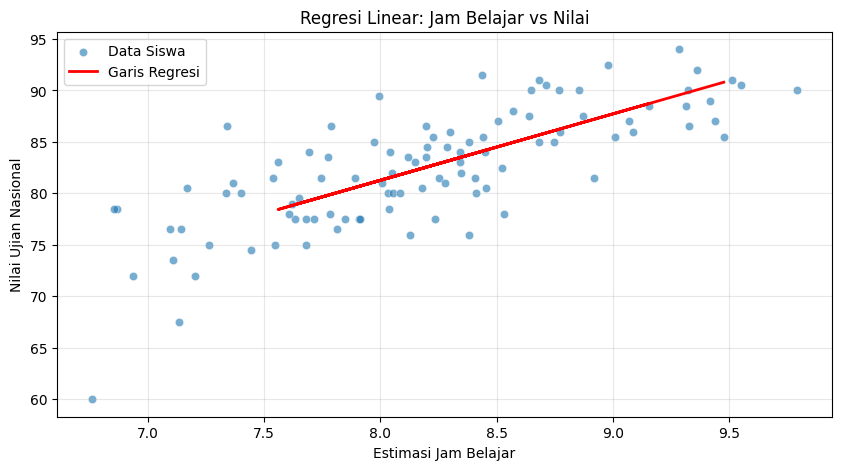


🔍 MULAI ANALISIS 2: REGRESI LOGISTIK
Proporsi Data: 50 Gagal, 50 Lulus
Akurasi Prediksi Kelulusan: 85.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


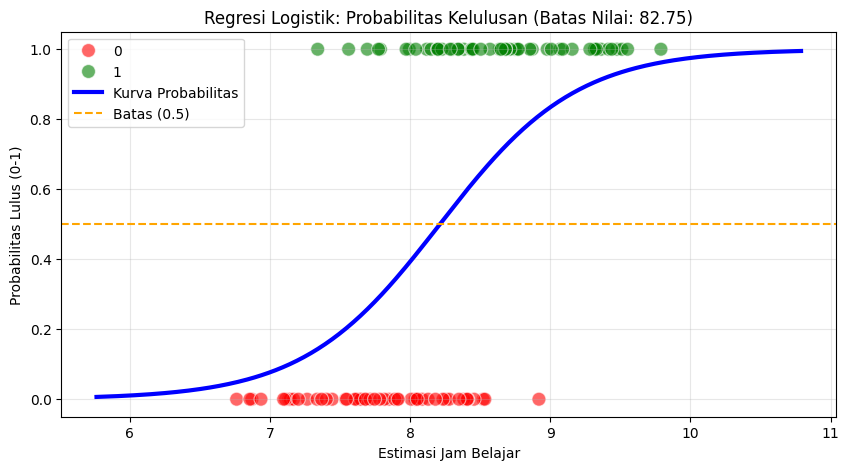


 BONUS: Analisis Nilai per Matkul


/tmp/ipython-input-4168716353.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=matkul_col, y=target_col, data=df, palette="Set2")


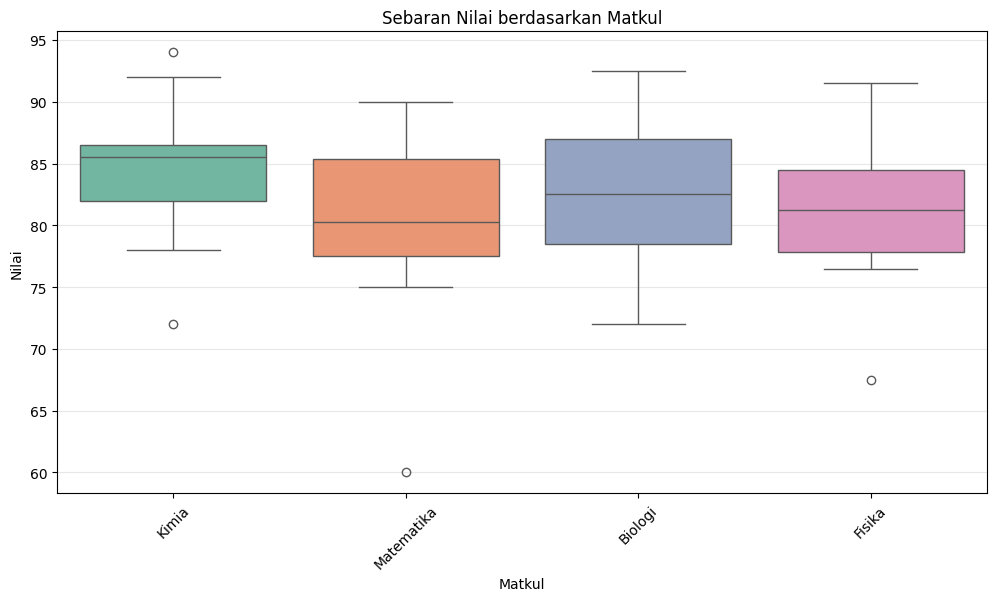


 Analisis Selesai!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

filename = 'Ujian_Nasional_Dataset.csv'

# ==========================================
# BAGIAN 1: MEMUAT & MEMERIKSA DATA
# ==========================================
print("📂 SEDANG MEMUAT DATASET...")

try:
    df = pd.read_csv(filename)
    print("✅ Dataset berhasil dimuat!")
    print("\nContoh 5 Data Teratas:")
    print(df.head())
    print("\nInformasi Kolom:")
    print(df.info())

    # Membersihkan nama kolom (menghapus spasi jika ada)
    df.columns = df.columns.str.strip()

    # Cek apakah kolom 'Nilai' ada
    target_col = 'Nilai' # Sesuaikan jika nama kolom di CSV berbeda (misal 'score')

    if target_col not in df.columns:
        # Fallback jika nama kolom berbeda, kita coba cari yang mirip
        cols = [c for c in df.columns if 'nilai' in c.lower() or 'score' in c.lower()]
        if cols:
            target_col = cols[0]
            print(f"⚠️ Kolom '{target_col}' ditemukan dan akan digunakan sebagai Target.")
        else:
            raise ValueError("Kolom 'Nilai' tidak ditemukan. Cek nama kolom di df.info()")

    # === PERBAIKAN: DATA CLEANING (MENGHAPUS NaN) ===
    # Menghapus baris yang memiliki nilai kosong pada kolom target
    null_count = df[target_col].isnull().sum()
    if null_count > 0:
        print(f"\n⚠️ Ditemukan {null_count} data kosong (NaN) pada kolom '{target_col}'.")
        print("🧹 Membersihkan data kosong...")
        df = df.dropna(subset=[target_col])
        print(f"✅ Data berhasil dibersihkan. Sisa data: {len(df)} baris.")
    else:
        print("\n✅ Tidak ditemukan data kosong (NaN).")

except FileNotFoundError:
    print(f"❌ ERROR: File '{filename}' tidak ditemukan.")
    print("👉 Pastikan Anda sudah upload file CSV ke Colab dan nama filenya sesuai.")
    # Membuat dummy data agar kode tetap jalan untuk demo
    print("\n⚠️ MEMBUAT DUMMY DATA SEMENTARA (Karena file asli belum ada)...")
    df = pd.DataFrame({
        'Nama': [f'Siswa {i}' for i in range(100)],
        'Nilai': np.random.normal(70, 15, 100).clip(0, 100),
        'Matkul': np.random.choice(['Matematika', 'Bahasa Indo', 'IPA'], 100)
    })
    target_col = 'Nilai'

# ==========================================
# BAGIAN 2: REKAYASA FITUR (FEATURE ENGINEERING)
# ==========================================
# Karena dataset asli mungkin tidak punya kolom "Jam Belajar",
# Kita akan mensimulasikannya berdasarkan 'Nilai' agar bisa latihan Regresi.
# Asumsi: Nilai tinggi biasanya hasil dari jam belajar yang tinggi.

print("\n⚙️ MELAKUKAN FEATURE ENGINEERING...")

# Kita balik logikanya: Perkirakan Jam Belajar dari Nilai (Inverse)
# Jam = (Nilai / 10) + Noise
# Ini membuat data "Jam Belajar" terlihat realistis sesuai Nilainya.
np.random.seed(42)
noise = np.random.normal(0, 0.5, len(df))
df['Estimasi_Jam_Belajar'] = (df[target_col] / 10) + noise

# Pastikan jam belajar tidak negatif dan masuk akal (0-12 jam)
df['Estimasi_Jam_Belajar'] = df['Estimasi_Jam_Belajar'].clip(0, 12)

# Cek ulang apakah ada NaN di hasil estimasi
df = df.dropna(subset=['Estimasi_Jam_Belajar'])

print("✅ Kolom simulasi 'Estimasi_Jam_Belajar' berhasil dibuat berdasarkan 'Nilai'.")

# ==========================================
# BAGIAN 3: REGRESI LINEAR
# ==========================================
print("\n🔍 MULAI ANALISIS 1: REGRESI LINEAR")
print(f"Tujuan: Memprediksi '{target_col}' berdasarkan 'Estimasi_Jam_Belajar'")

X = df[['Estimasi_Jam_Belajar']]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Model: Nilai = {lin_reg.intercept_:.2f} + {lin_reg.coef_[0]:.2f} * Jam_Belajar")

# Visualisasi
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Estimasi_Jam_Belajar'], y=df[target_col], alpha=0.6, label='Data Siswa')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Garis Regresi')
plt.title(f'Regresi Linear: Jam Belajar vs {target_col}')
plt.xlabel('Estimasi Jam Belajar')
plt.ylabel(f'{target_col} Ujian Nasional')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# BAGIAN 4: REGRESI LOGISTIK (DIPERBAIKI AGAR PASTI JALAN)
# ==========================================
print("\n🔍 MULAI ANALISIS 2: REGRESI LOGISTIK")

# --- PERBAIKAN LOGIKA STATUS LULUS ---
# Alih-alih pakai nilai mati (55), kita bagi data jadi 2:
# 50% Nilai Terendah = Gagal (0), 50% Nilai Tertinggi = Lulus (1)
# Ini MENJAMIN pasti ada 2 kelas (0 dan 1).

median_score = df[target_col].median()
df['Status_Lulus'] = df[target_col].apply(lambda x: 1 if x >= median_score else 0)

# Pengecekan Terakhir (Safety Net):
# Jika karena suatu alasan datanya masih 1 jenis saja, kita paksa ubah sebagian.
if df['Status_Lulus'].nunique() < 2:
    print("⚠️ Data terlalu seragam, membagi paksa data menjadi Lulus/Gagal untuk demo.")
    # Urutkan berdasarkan nilai, separuh bawah jadi 0, separuh atas jadi 1
    df = df.sort_values(by=target_col)
    half_index = len(df) // 2
    df.iloc[:half_index, df.columns.get_loc('Status_Lulus')] = 0
    df.iloc[half_index:, df.columns.get_loc('Status_Lulus')] = 1

# Cek jumlah data per kelas
counts = df['Status_Lulus'].value_counts()
print(f"Proporsi Data: {counts.get(0,0)} Gagal, {counts.get(1,0)} Lulus")

# --- PROSES TRAINING ---
y_log = df['Status_Lulus']
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42, stratify=y_log)

log_reg = LogisticRegression()
log_reg.fit(X_train_log, y_train_log)

acc = accuracy_score(y_test_log, log_reg.predict(X_test_log))
print(f"Akurasi Prediksi Kelulusan: {acc*100:.1f}%")

# --- VISUALISASI SIGMOID ---
plt.figure(figsize=(10, 5))

# Scatter Plot Data Asli
sns.scatterplot(x=df['Estimasi_Jam_Belajar'], y=df['Status_Lulus'],
                hue=df['Status_Lulus'], palette={0:'red', 1:'green'},
                s=100, alpha=0.6)

# Membuat Garis Kurva Sigmoid
# Kita buat range X yang lebih lebar agar kurva S terlihat utuh
X_range = np.linspace(df['Estimasi_Jam_Belajar'].min() - 1, df['Estimasi_Jam_Belajar'].max() + 1, 300).reshape(-1, 1)
y_sigmoid = log_reg.predict_proba(X_range)[:, 1]

plt.plot(X_range, y_sigmoid, color='blue', linewidth=3, label='Kurva Probabilitas')
plt.axhline(0.5, color='orange', linestyle='--', label='Batas (0.5)')

plt.title(f'Regresi Logistik: Probabilitas Kelulusan (Batas Nilai: {median_score})')
plt.xlabel('Estimasi Jam Belajar')
plt.ylabel('Probabilitas Lulus (0-1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


col_matkul = [c for c in df.columns if 'matkul' in c.lower() or 'pelajaran' in c.lower() or 'subject' in c.lower()]

if col_matkul:
    matkul_col = col_matkul[0]
    print(f"\n BONUS: Analisis Nilai per {matkul_col}")

    plt.figure(figsize=(12, 6))
    sns.boxplot(x=matkul_col, y=target_col, data=df, palette="Set2")
    plt.title(f'Sebaran {target_col} berdasarkan {matkul_col}')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()
else:
    print("\n(Tidak ditemukan kolom Mata Pelajaran untuk analisis bonus)")

print("\n Analisis Selesai!")